# SyriaTel Customer Churn Analysis
## Overview
This analysis aims to help SyriaTel, a telecommunications company, reduce revenue loss caused by customer churn. By identifying customers who are likely to leave, SyriaTel can take proactive steps to retain them before it's too late.

## Business Understanding
Every customer who churns represents lost revenue for SyriaTel. The key business question is:

*Are there predictable patterns in customer behavior that signal they are about to leave?*

If we can answer yes, SyriaTel's retention team can intervene early — offering deals or support to at-risk customers — and reduce the amount of money lost to churn.

# Data Understanding
Let's explore the dataset to understand its structure and check for any issues.

In [1]:
# Importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Load the dataset
df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
# Check for nulls and data types
print(df.info())    
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

The dataset contains 3,333 customer records with 21 features including call usage, charges, and plan information. There are no missing values. The target variable is churn — whether a customer left SyriaTel or not.

In [3]:
# check the churn distribution
df['churn'].value_counts()

False    2850
True      483
Name: churn, dtype: int64

The dataset is imbalanced — only 14.5% of customers churned (483 out of 3,333). This means our model needs to be evaluated carefully, as accuracy alone can be misleading.

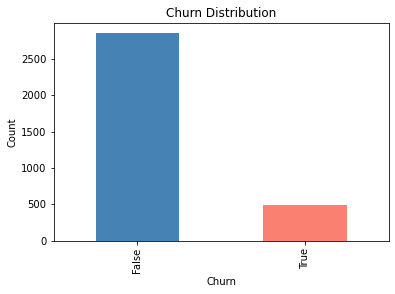

In [11]:
# Churn distribution plot
df['churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

The bar chart confirms the class imbalance — the majority of customers did not churn (2,850) compared to those who did (483). This means our model must be evaluated carefully beyond just accuracy.

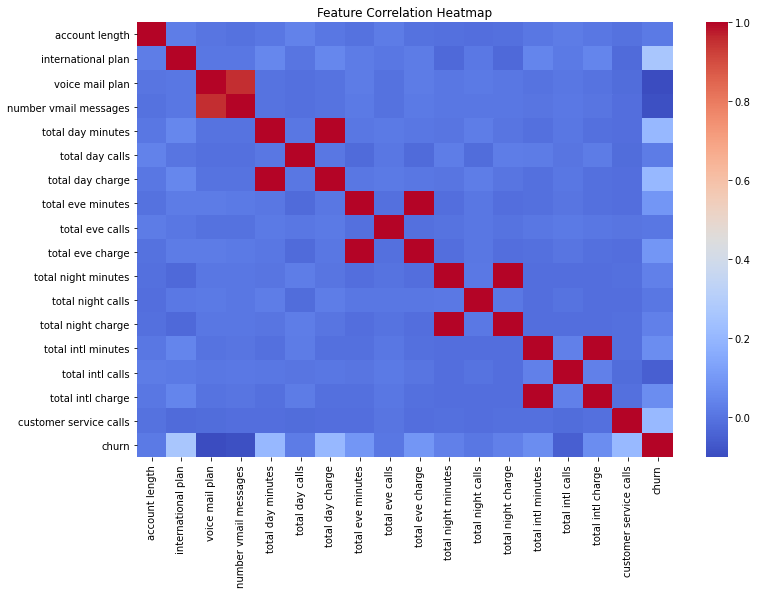

In [12]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The correlation heatmap shows relationships between features. The red squares along the diagonal confirm that each feature correlates perfectly with itself. Notably, the minutes and charge columns for each time period (day, evening, night, international) are strongly correlated with each other — meaning if a customer calls more minutes, they get charged more. The churn column at the bottom shows weak correlations with most features, meaning no single feature alone predicts churn perfectly.

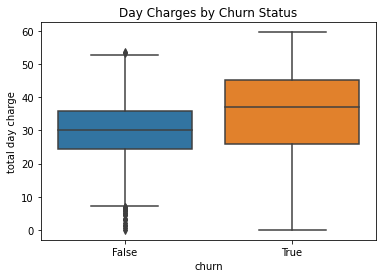

In [13]:
# Day charges vs churn
sns.boxplot(x='churn', y='total day charge', data=df)
plt.title('Day Charges by Churn Status')
plt.show()

Customers who churned (True) tend to have higher day charges compared to those who stayed (False). This suggests that customers who are charged more for daytime calls are more likely to leave SyriaTel — possibly switching to a cheaper competitor. This is a key insight for the retention team.

## Data Preparation
Here we clean and prepare the data for modeling by encoding categorical variables, dropping irrelevant columns, and splitting into training and test sets.

In [4]:
# Drop irrelevant columns
df = df.drop(columns=['phone number', 'state', 'area code'])

# Encode categorical columns
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

# Define features and target
X = df.drop(columns=['churn'])
y = df['churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (2666, 17)
Test set size: (667, 17)


## Modeling
We build three models iteratively. We start with Logistic Regression as a baseline, then a Decision Tree, then a tuned Decision Tree with optimized hyperparameters.

In [8]:
# logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, lr_preds))

Logistic Regression Results:
              precision    recall  f1-score   support

       False       0.87      0.98      0.92       566
        True       0.58      0.18      0.27       101

    accuracy                           0.86       667
   macro avg       0.73      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667



In [9]:
# decision tree model
from sklearn.tree import DecisionTreeClassifier

# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, dt_preds))

Decision Tree Results:
              precision    recall  f1-score   support

       False       0.95      0.96      0.96       566
        True       0.76      0.73      0.74       101

    accuracy                           0.92       667
   macro avg       0.85      0.85      0.85       667
weighted avg       0.92      0.92      0.92       667



In [7]:
# Tuned Decision Tree
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_tuned.fit(X_train, y_train)
dt_tuned_preds = dt_tuned.predict(X_test)

print("Tuned Decision Tree Results:")
print(classification_report(y_test, dt_tuned_preds))

Tuned Decision Tree Results:
              precision    recall  f1-score   support

       False       0.94      0.98      0.96       566
        True       0.88      0.66      0.76       101

    accuracy                           0.94       667
   macro avg       0.91      0.82      0.86       667
weighted avg       0.93      0.94      0.93       667



## Evaluation
Three models were built iteratively:

- *Logistic Regression* (baseline): Poor churn recall of 18% — misses most churners
- *Decision Tree*: Strong recall of 73% — catches most churners
- *Tuned Decision Tree*: Best accuracy (94%) and precision (88%) — fewer false alarms

The *Tuned Decision Tree is our final recommended model*. It balances catching churners while minimizing false positives, making it practical for SyriaTel's retention 

In [10]:
# Evaluate final model on both training and test data
train_preds = dt_tuned.predict(X_train)
print("Training Performance:")
print(classification_report(y_train, train_preds))

print("Test Performance:")
print(classification_report(y_test, dt_tuned_preds))

Training Performance:
              precision    recall  f1-score   support

       False       0.96      0.99      0.97      2284
        True       0.94      0.73      0.82       382

    accuracy                           0.95      2666
   macro avg       0.95      0.86      0.90      2666
weighted avg       0.95      0.95      0.95      2666

Test Performance:
              precision    recall  f1-score   support

       False       0.94      0.98      0.96       566
        True       0.88      0.66      0.76       101

    accuracy                           0.94       667
   macro avg       0.91      0.82      0.86       667
weighted avg       0.93      0.94      0.93       667



The Tuned Decision Tree achieves 95% accuracy on training data and 94% on test data. The small difference between training and test performance confirms the model is *not overfitting* — it generalizes well to new, unseen customers. This makes it reliable for real-world use by SyriaTel.

## Recommendations & Next Steps

Based on our analysis, we recommend the following to SyriaTel:

1. *Deploy the Tuned Decision Tree model* to automatically flag customers who are likely to churn.

2. *Focus retention efforts* on customers with high day charges and frequent customer service calls — these are strong churn indicators.

3. *Offer targeted incentives* such as discounts or plan upgrades to customers flagged as high churn risk.

4. *Act early* — the sooner the retention team reaches out to at-risk customers, the better the chance of keeping them.

### Next Steps
- Try a Random Forest model for potentially better performance
- Address class imbalance using SMOTE to improve churn recall further
- Monitor model performance over time as new customer data comes in
- Collect more data on why customers churn to improve future models

## Thank You
Thank you for reviewing this analysis. By predicting which customers are likely to leave before they do, SyriaTel can take proactive steps to retain them and significantly reduce revenue loss.